In [1]:
!pip install -q xgboost openpyxl scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from google.colab import files, drive

from sklearn.model_selection import GroupShuffleSplit

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_PATH = "/content/drive/MyDrive/PCOS_Flo_Project"

os.makedirs(
    PROJECT_PATH,
    exist_ok=True
)

print("Project folder:")
print(PROJECT_PATH)


Project folder:
/content/drive/MyDrive/PCOS_Flo_Project


In [5]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("\nDataset selected:")
print(file_name)


Saving FEMCARE_Menstrual_Dataset_5000.xlsx to FEMCARE_Menstrual_Dataset_5000.xlsx

Dataset selected:
FEMCARE_Menstrual_Dataset_5000.xlsx


In [6]:
df = pd.read_excel(
    file_name,
    sheet_name="FEMCARE_Dataset"
)

In [7]:
print("\n========================================")
print("DATASET INFORMATION")
print("========================================")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
for i, column in enumerate(df.columns, 1):
    print(i, "->", column)


DATASET INFORMATION
Rows: 5000
Columns: 15

Columns:
1 -> User_ID
2 -> Cycle_Number
3 -> Period_Start_Date
4 -> Period_End_Date
5 -> Cycle_Length
6 -> Period_Duration
7 -> Flow
8 -> Cramps
9 -> Headache
10 -> Bloating
11 -> Acne
12 -> Fatigue
13 -> Mood
14 -> Stress
15 -> Sleep


In [8]:

print("\nFirst 5 rows:")

display(df.head())



First 5 rows:


,User_ID,Cycle_Number,Period_Start_Date,Period_End_Date,Cycle_Length,Period_Duration,Flow,Cramps,Headache,Bloating,Acne,Fatigue,Mood,Stress,Sleep
0,U0001,1,2021-04-10,2021-04-15,NaN,6,Medium,Mild,NaN,Mild,Mild,NaN,Sad,Low,Poor
1,U0001,2,2021-05-09,2021-05-13,32.0,5,Medium,Mild,Severe,Severe,NaN,Moderate,Anxious,NaN,Fair
2,U0001,3,2021-06-10,2021-06-14,33.0,5,Heavy,Severe,NaN,Mild,Moderate,Moderate,Happy,High,Fair
3,U0001,4,2021-07-13,2021-07-16,33.0,4,Medium,Moderate,Mild,Moderate,NaN,Severe,Irritable,High,Good
4,U0001,5,2021-08-15,2021-08-18,27.0,4,Medium,Moderate,Moderate,Moderate,Mild,Mild,Sad,High,Fair


In [9]:
print("\nData types:")

print(df.dtypes)


Data types:
User_ID               object
Cycle_Number           int64
Period_Start_Date     object
Period_End_Date       object
Cycle_Length         float64
Period_Duration        int64
Flow                  object
Cramps                object
Headache              object
Bloating              object
Acne                  object
Fatigue               object
Mood                  object
Stress                object
Sleep                 object
dtype: object


In [10]:
print("\nMissing values:")

missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ]
)


Missing values:
Cycle_Length     500
Cramps           884
Headache        2217
Bloating        1525
Acne            2033
Fatigue         1032
Stress           967
dtype: int64


In [11]:
df["Period_Start_Date"] = pd.to_datetime(
    df["Period_Start_Date"],
    errors="coerce"
)

df["Period_End_Date"] = pd.to_datetime(
    df["Period_End_Date"],
    errors="coerce"
)

df = df.sort_values(
    by=[
        "User_ID",
        "Period_Start_Date"
    ]
).reset_index(drop=True)

In [12]:
df["Next_Cycle_Length"] = (
    df.groupby("User_ID")["Cycle_Length"]
      .shift(-1)
)


In [13]:
df["Previous_Cycle_1"] = (
    df.groupby("User_ID")["Cycle_Length"]
      .shift(1)
)

df["Previous_Cycle_2"] = (
    df.groupby("User_ID")["Cycle_Length"]
      .shift(2)
)

df["Previous_Cycle_3"] = (
    df.groupby("User_ID")["Cycle_Length"]
      .shift(3)
)


In [14]:
df["Previous_Cycle_Average"] = (
    df[
        [
            "Previous_Cycle_1",
            "Previous_Cycle_2",
            "Previous_Cycle_3"
        ]
    ].mean(axis=1)
)

df["Previous_Cycle_Std"] = (
    df[
        [
            "Previous_Cycle_1",
            "Previous_Cycle_2",
            "Previous_Cycle_3"
        ]
    ].std(axis=1)
)


In [15]:
df["Start_Month"] = (
    df["Period_Start_Date"].dt.month
)

df["Start_Day"] = (
    df["Period_Start_Date"].dt.day
)

df["Start_Weekday"] = (
    df["Period_Start_Date"].dt.weekday
)

In [16]:
df_model = df[
    df["Next_Cycle_Length"].notna()
].copy()

In [17]:
df_model = df_model[
    df_model["Cycle_Length"].notna()
].copy()


In [18]:
df_model = df_model[
    (df_model["Cycle_Length"] > 0) &
    (df_model["Next_Cycle_Length"] > 0)
].copy()

In [19]:
features = [

    "Cycle_Number",

    "Cycle_Length",

    "Period_Duration",

    "Flow",

    "Cramps",

    "Headache",

    "Bloating",

    "Acne",

    "Fatigue",

    "Mood",

    "Stress",

    "Sleep",

    "Previous_Cycle_1",

    "Previous_Cycle_2",

    "Previous_Cycle_3",

    "Previous_Cycle_Average",

    "Previous_Cycle_Std",

    "Start_Month",

    "Start_Day",

    "Start_Weekday"
]

In [20]:
target = "Next_Cycle_Length"

In [21]:
X = df_model[features].copy()

y = df_model[target].copy()


In [22]:
print("\n========================================")
print("FEATURES USED FOR TRAINING")
print("========================================")

for i, feature in enumerate(features, 1):
    print(i, "->", feature)


print("\nTarget:")
print(target)

print("\nTraining rows:")
print(len(X))




FEATURES USED FOR TRAINING
1 -> Cycle_Number
2 -> Cycle_Length
3 -> Period_Duration
4 -> Flow
5 -> Cramps
6 -> Headache
7 -> Bloating
8 -> Acne
9 -> Fatigue
10 -> Mood
11 -> Stress
12 -> Sleep
13 -> Previous_Cycle_1
14 -> Previous_Cycle_2
15 -> Previous_Cycle_3
16 -> Previous_Cycle_Average
17 -> Previous_Cycle_Std
18 -> Start_Month
19 -> Start_Day
20 -> Start_Weekday

Target:
Next_Cycle_Length

Training rows:
4000


In [23]:
categorical_features = [

    "Flow",

    "Cramps",

    "Headache",

    "Bloating",

    "Acne",

    "Fatigue",

    "Mood",

    "Stress",

    "Sleep"
]


In [24]:
numerical_features = [

    "Cycle_Number",

    "Cycle_Length",

    "Period_Duration",

    "Previous_Cycle_1",

    "Previous_Cycle_2",

    "Previous_Cycle_3",

    "Previous_Cycle_Average",

    "Previous_Cycle_Std",

    "Start_Month",

    "Start_Day",

    "Start_Weekday"
]

In [25]:
print("\n========================================")
print("CATEGORICAL FEATURES")
print("========================================")

for feature in categorical_features:
    print("->", feature)


print("\n========================================")
print("NUMERICAL FEATURES")
print("========================================")

for feature in numerical_features:
    print("->", feature)


CATEGORICAL FEATURES
-> Flow
-> Cramps
-> Headache
-> Bloating
-> Acne
-> Fatigue
-> Mood
-> Stress
-> Sleep

NUMERICAL FEATURES
-> Cycle_Number
-> Cycle_Length
-> Period_Duration
-> Previous_Cycle_1
-> Previous_Cycle_2
-> Previous_Cycle_3
-> Previous_Cycle_Average
-> Previous_Cycle_Std
-> Start_Month
-> Start_Day
-> Start_Weekday


In [27]:
groups = df_model["User_ID"]


gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)


train_index, test_index = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()


print("\n========================================")
print("TRAIN / TEST SPLIT")
print("========================================")

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print(
    "Training users:",
    df_model.iloc[train_index]["User_ID"].nunique()
)

print(
    "Testing users:",
    df_model.iloc[test_index]["User_ID"].nunique()
)



TRAIN / TEST SPLIT
Training rows: 3232
Testing rows : 768
Training users: 400
Testing users: 100


In [28]:
numeric_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )

    ]
)
categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]
)
preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]
)


In [29]:
model = XGBRegressor(

    # Number of trees
    n_estimators=500,

    # Tree depth
    max_depth=5,

    # Learning rate
    learning_rate=0.03,

    # Row sampling
    subsample=0.85,

    # Feature sampling
    colsample_bytree=0.85,

    # Minimum child weight
    min_child_weight=2,

    # Regularization
    reg_alpha=0.0,

    reg_lambda=1.0,

    # Regression objective
    objective="reg:squarederror",
    # Evaluation metric
    eval_metric="rmse",

    # Reproducibility
    random_state=42,

    # Use all CPU cores
    n_jobs=-1
)


In [30]:
pipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )

    ]
)

In [31]:
print("\n========================================")
print("TRAINING XGBOOST REGRESSOR")
print("========================================")

pipeline.fit(
    X_train,
    y_train
)

print("\nTraining completed successfully!")


TRAINING XGBOOST REGRESSOR

Training completed successfully!


In [32]:
y_pred = pipeline.predict(
    X_test
)

In [33]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)
print("\n========================================")
print("MODEL PERFORMANCE")
print("========================================")

print(
    f"MAE  : {mae:.2f} days"
)

print(
    f"RMSE : {rmse:.2f} days"
)

print(
    f"R²   : {r2:.4f}"
)


MODEL PERFORMANCE
MAE  : 1.89 days
RMSE : 2.29 days
R²   : 0.5274


In [34]:
within_1_day = (
    np.abs(
        y_test.values - y_pred
    ) <= 1
).mean() * 100

In [35]:
within_2_days = (
    np.abs(
        y_test.values - y_pred
    ) <= 2
).mean() * 100

In [36]:

within_3_days = (
    np.abs(
        y_test.values - y_pred
    ) <= 3
).mean() * 100


print("\nPrediction tolerance:")

print(
    f"Within ±1 day : {within_1_day:.2f}%"
)

print(
    f"Within ±2 days: {within_2_days:.2f}%"
)

print(
    f"Within ±3 days: {within_3_days:.2f}%"
)



Prediction tolerance:
Within ±1 day : 30.34%
Within ±2 days: 57.68%
Within ±3 days: 79.43%


In [38]:
results = pd.DataFrame({

    "Actual_Next_Cycle": y_test.values,

    "Predicted_Next_Cycle": np.round(
        y_pred,
        2
    )

})


results["Error_Days"] = (
    results["Predicted_Next_Cycle"]
    -
    results["Actual_Next_Cycle"]
)

print("\n========================================")
print("SAMPLE PREDICTIONS")
print("========================================")

display(
    results.head(20)
)




SAMPLE PREDICTIONS


,Actual_Next_Cycle,Predicted_Next_Cycle,Error_Days
0,33.0,31.730000,-1.270000
1,33.0,31.799999,-1.200001
2,27.0,32.730000,5.730000
3,32.0,28.309999,-3.690001
4,33.0,30.350000,-2.650000
5,30.0,29.719999,-0.280001
6,31.0,30.780001,-0.219999
7,28.0,28.790001,0.790001
8,27.0,27.870001,0.870001
9,26.0,28.100000,2.100000


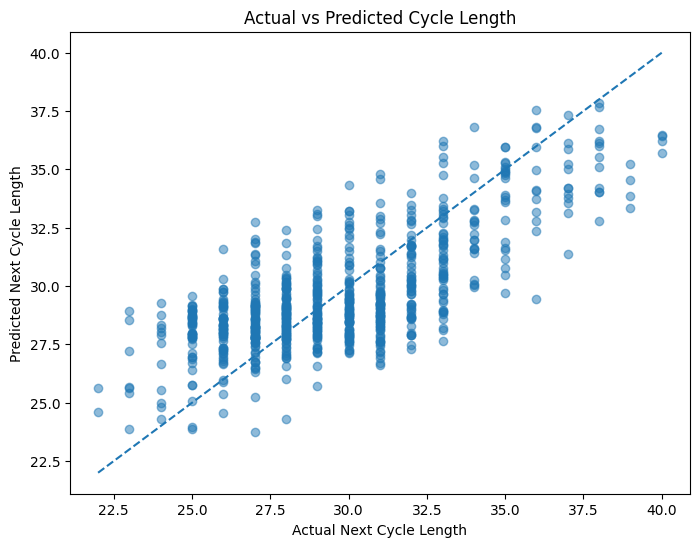

In [39]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel(
    "Actual Next Cycle Length"
)

plt.ylabel(
    "Predicted Next Cycle Length"
)

plt.title(
    "Actual vs Predicted Cycle Length"
)
minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()



In [40]:
model_path = os.path.join(
    PROJECT_PATH,
    "cycle_prediction_xgboost_pipeline.pkl"
)


joblib.dump(
    pipeline,
    model_path
)


print("\n========================================")
print("MODEL SAVED")
print("========================================")

print(model_path)


MODEL SAVED
/content/drive/MyDrive/PCOS_Flo_Project/cycle_prediction_xgboost_pipeline.pkl


In [41]:
feature_info = {

    "target": target,

    "features": features,

    "categorical_features":
        categorical_features,

    "numerical_features":
        numerical_features

}
feature_info_path = os.path.join(
    PROJECT_PATH,
    "cycle_prediction_feature_info.pkl"
)


joblib.dump(
    feature_info,
    feature_info_path
)


['/content/drive/MyDrive/PCOS_Flo_Project/cycle_prediction_feature_info.pkl']

In [42]:
results_path = os.path.join(
    PROJECT_PATH,
    "cycle_prediction_test_results.csv"
)


results.to_csv(
    results_path,
    index=False
)

In [44]:
performance = pd.DataFrame({

    "Metric": [

        "MAE_days",

        "RMSE_days",

        "R2",

        "Within_1_day_percent",

        "Within_2_days_percent",

        "Within_3_days_percent"

    ],
"Value": [

        mae,

        rmse,

        r2,

        within_1_day,

        within_2_days,

        within_3_days

    ]

})
performance_path = os.path.join(
    PROJECT_PATH,
    "cycle_prediction_performance.csv"
)


performance.to_csv(
    performance_path,
    index=False
)

In [45]:
sample_input = X_test.iloc[[0]].copy()


sample_prediction = pipeline.predict(
    sample_input
)[0]


print("\n========================================")
print("SINGLE USER TEST")
print("========================================")

print(
    "Predicted next cycle length:",
    round(sample_prediction, 2),
    "days"
)


SINGLE USER TEST
Predicted next cycle length: 31.73 days


In [47]:
sample_row = df_model.iloc[
    test_index[0]
]


current_period_date = pd.to_datetime(
    sample_row["Period_Start_Date"]
)


predicted_days = round(
    sample_prediction
)


predicted_next_period = (
    current_period_date
    +
    pd.Timedelta(
        days=predicted_days
    )
)
print(
    "Current period start:",
    current_period_date.date()
)

print(
    "Predicted next period:",
    predicted_next_period.date()
)

Current period start: 2021-05-09
Predicted next period: 2021-06-10


In [48]:
print("\n========================================")
print("CYCLE PREDICTION MODEL READY")
print("========================================")

print(
    "Model type: XGBoost Regressor"
)

print(
    "Target: Next menstrual cycle length"
)

print(
    f"MAE: {mae:.2f} days"
)

print(
    f"RMSE: {rmse:.2f} days"
)

print(
    f"R²: {r2:.4f}"
)
print(
    f"Within ±2 days: {within_2_days:.2f}%"
)

print("\nFiles saved in:")

print(PROJECT_PATH)

print("\nSaved files:")

print(
    "1. cycle_prediction_xgboost_pipeline.pkl"
)

print(
    "2. cycle_prediction_feature_info.pkl"
)

print(
    "3. cycle_prediction_test_results.csv"
)

print(
    "4. cycle_prediction_performance.csv"
)

print("\n========================================")


CYCLE PREDICTION MODEL READY
Model type: XGBoost Regressor
Target: Next menstrual cycle length
MAE: 1.89 days
RMSE: 2.29 days
R²: 0.5274
Within ±2 days: 57.68%

Files saved in:
/content/drive/MyDrive/PCOS_Flo_Project

Saved files:
1. cycle_prediction_xgboost_pipeline.pkl
2. cycle_prediction_feature_info.pkl
3. cycle_prediction_test_results.csv
4. cycle_prediction_performance.csv

